## Titanic Data Visualization Project

### Overview
This project explores the Titanic dataset to analyze passenger survival patterns using data visualization techniques. The goal is to uncover insights about survival rates based on gender, class, age, and other features.

### Dataset

The dataset used in this project is the famous Titanic dataset which contains information about passengers including:

Passenger class

Age

Gender

Fare

Survival status
### Objectives

Understand survival patterns

Practice data visualization skills

Perform exploratory data analysis (EDA)

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# load Sample data
data = pd.read_csv(r"D:\Desktop\DEPI's Materials\Session_Material PY.S10(Data Visualization)\Assignment_WxyKYAk\Titanic.csv")



In [ ]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


Text(0.5, 1.0, 'Scatter Plot of Age vs Fare')

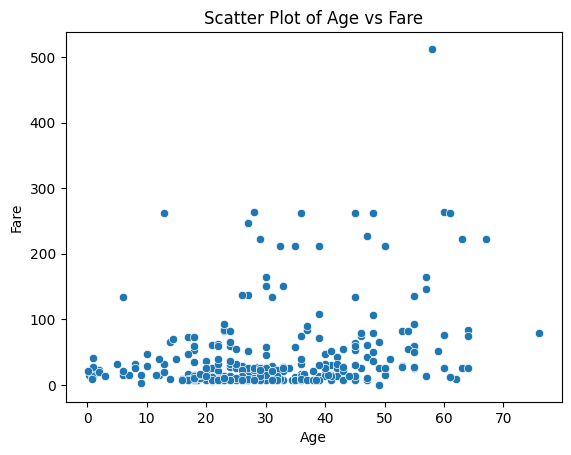

In [ ]:
#scatter plot
sns.scatterplot(x=data['Age'], y=data['Fare'])
plt.title('Scatter Plot of Age vs Fare')



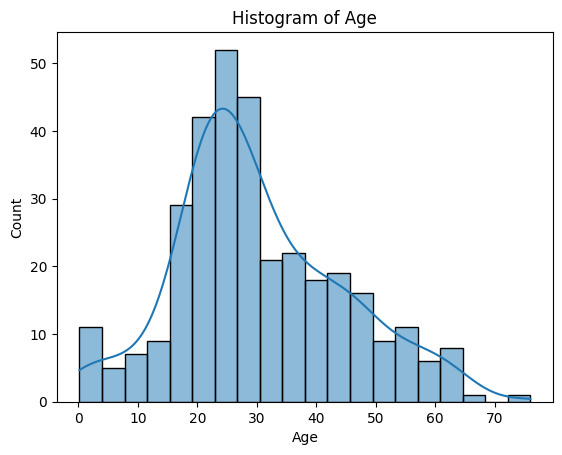

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data['Age'], bins=20, kde=True)

plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Histogram of Age')

plt.show()


<Axes: xlabel='Sex', ylabel='count'>

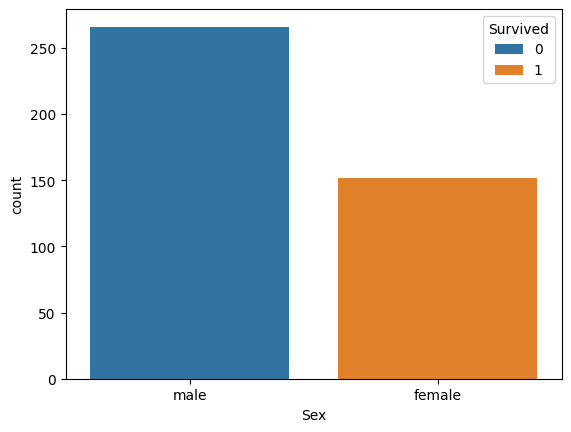

In [ ]:
sns.countplot(data=data, x='Sex', hue='Survived')


Text(0.5, 1.0, 'Box Plot of Fare by Pclass')

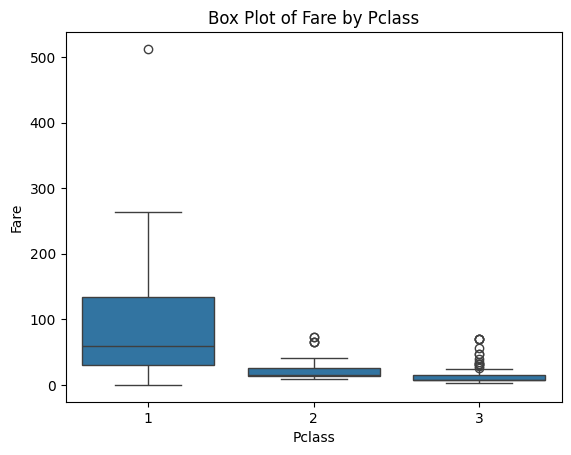

In [ ]:
#box plot
sns.boxplot(x=data['Pclass'], y=data['Fare'])
plt.title('Box Plot of Fare by Pclass')

<Axes: xlabel='Pclass', ylabel='count'>

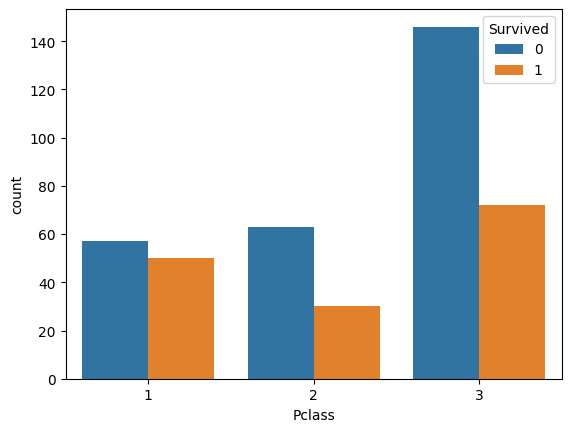

In [ ]:
sns.countplot(data=data, x='Pclass', hue='Survived')

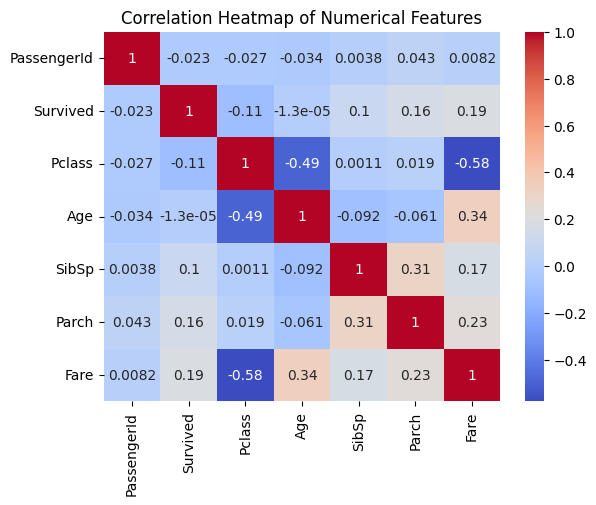

In [ ]:
#select numerical columns
numerical_cols = data.select_dtypes(include=['float64', 'int64'])
#compute correlation matrix
correlation_matrix = numerical_cols.corr()
#plot heatmap
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


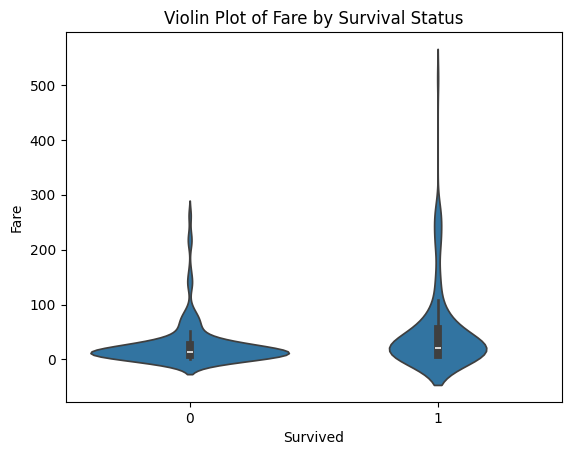

In [ ]:
#violen plot
sns.violinplot(x= 'Survived', y = 'Fare' , data = data)
plt.title('Violin Plot of Fare by Survival Status')
plt.show()

In [ ]:
# sns.pairplot(data)
# plt.show()

In [5]:
pip install dash plotly

  Using cached dash-4.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached importlib_metadata-8.7.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached retrying-1.4.2-py3-none-any.whl.metadata (5.5 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached zipp-3.23.0-py3-none-any.whl.metadata (3.6 kB)
Using cached dash-4.0.0-py3-none-any.whl (7.2 MB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
Using cached click-8.3.1-py3-none-any.whl (108 kB)
Using cached itsdangerous-2.2.0-py3-none-any.whl (16 kB)
Using cached importlib_metadata-8.7.1-py3-none-any.whl (27 kB)
Using cached zipp-3.23.0-py3-none-any.whl (10 kB)
Using cached retrying-1.4.2-py3-none-any.whl (10 kB)

   ---- ----------------------------------- 1/9 [Werkzeug]
   ---- ----------------------------------- 1/9 [Werkzeug]
   ---- ----------------------------------- 1/9

In [6]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
import pandas as pd

In [7]:
app = dash.Dash(__name__)
df = data

In [8]:
survival_counts = df['Survived'].value_counts().reset_index()
survival_counts.columns = ['Survived', 'Count']

survival_counts['Survived'] = survival_counts['Survived'].map({
    0: 'Did Not Survive',
    1: 'Survived'
})

# نعمل الرسم
fig = px.bar(
    survival_counts,
    x='Survived',
    y='Count',
    color='Survived',
    title="Survival Count on the Titanic"
)

In [9]:
app.layout = html.Div(children = [

    html.H1("Titanic Dashboard"),

    html.Div("Simple analysis of Titanic survival data."),

    dcc.Graph(
        id='survival-graph',
        figure=fig
    )
])

In [10]:
if __name__ == '__main__':
    app.run(debug=True)